# Notebook 05 Data Wrangling & EDA: Stress Indicators
**Proyek Analisis Data: HAPI (Human Activity Pattern Intelligence)**

### Profil Proyek & Tim
- **Tema Capstone:** Healthy Lives & Well-being
- **Target User:** Mahasiswa (fokus pada aspek akademik & lingkungan belajar)
- **Tujuan Proyek:** Pengembangan *platform* Webapp untuk *mood management & tracker* serta diagnosis mandiri tingkat kelelahan (*fatigue*).
- **Tim DS:** Greycia Febrina Michelle (CDCC700D6X2644) & Khazel Hayfa Yosmi (CDCC308D6X0629)

### Tujuan Notebook
Melakukan Data Wrangling (*Gathering, Assessing, Cleaning*) dan Exploratory Data Analysis (EDA) pada dataset Stress Indicators. Dataset ini digunakan sebagai dataset **supporting** untuk mengidentifikasi pola stres yang dialami mahasiswa, menjawab *business questions*, serta menghasilkan *insight* yang akan diintegrasikan ke dalam Dashboard Streamlit HAPI.

### Asal Dataset
Dataset yang digunakan dalam analisis ini adalah **Stress Indicators Dataset** yang diperoleh dari Mendeley Data. Dataset ini dipilih karena menyediakan berbagai indikator yang berkaitan dengan tingkat stres individu, termasuk faktor psikologis, perilaku, dan lingkungan yang relevan untuk memahami tekanan akademik pada mahasiswa. Informasi yang dihasilkan dari dataset ini diharapkan dapat melengkapi analisis utama terkait burnout dan fatigue dalam ekosistem HAPI.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from matplotlib.colors import LinearSegmentedColormap

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

PALETTE = ['#00bcff','#00adfd','#009efa','#008ff6','#007ff1',
           '#006eea','#005ce1','#004ad6','#0034c8']
C_MAIN = '#007ff1'
C_DARK = '#0034c8'
C_LIGHT = '#00bcff'
C_GREY = '#e0e0e0'
HAPI_CMAP = LinearSegmentedColormap.from_list('hapi', [C_LIGHT, C_DARK], N=256)

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11,
})

ROOT = Path.cwd()
for _ in range(5):
    if (ROOT / 'data').exists():
        break
    ROOT = ROOT.parent

RAW_PATH   = ROOT / 'data' / 'raw' / 'supporting' / 'kelompok1-prediksi-burnout-dan-fatigue' / 'stress_indicators.csv'
CLEAN_PATH = ROOT / 'data' / 'clean' / 'supporting' / 'stress_indicators_clean.csv'
CLEAN_PATH.parent.mkdir(parents=True, exist_ok=True)

DROP_COLS = ['heartbeat_palpitations', 'weight_changes', 'health_issues', 'work_environment']
ACADEMIC_COLS = [
    'academic_overload', 'peer_competition', 'low_academic_confidence',
    'subject_confidence', 'academic_conflicts', 'class_attendance',
    'professor_difficulties', 'concentration_problems'
]

print(f'ROOT     : {ROOT}')
print(f'File ada : {RAW_PATH.exists()}')
print('Setup selesai.')

ROOT     : d:\Proyek_Analisis_Burnout
File ada : True
Setup selesai.


**Inisialisasi Lingkungan Kerja**

Setup mendeteksi root direktori proyek secara otomatis menggunakan `pathlib`, sehingga notebook dapat dijalankan dari mesin manapun tanpa perlu mengubah path secara manual.

Palet warna yang digunakan adalah spektrum biru monokromatik HAPI (`#00bcff` sampai `#0034c8`). Warna lebih gelap merepresentasikan nilai atau intensitas lebih tinggi sesuai prinsip *darker-is-more*.

## Gathering Data

In [2]:
df_raw = pd.read_csv(RAW_PATH)
print(f'Dataset dimuat: {df_raw.shape[0]:,} baris, {df_raw.shape[1]} kolom')
print(f'Kolom: {df_raw.columns.tolist()}')
df_raw.head()

Dataset dimuat: 2,000 baris, 26 kolom
Kolom: ['gender', 'age', 'stress_experience', 'heartbeat_palpitations', 'anxiety_tension', 'sleep_problems', 'restlessness', 'headaches', 'irritability', 'concentration_problems', 'sadness_low_mood', 'health_issues', 'loneliness_isolation', 'academic_overload', 'peer_competition', 'relationship_stress', 'professor_difficulties', 'work_environment', 'lack_relaxation_time', 'home_environment', 'low_academic_confidence', 'subject_confidence', 'academic_conflicts', 'class_attendance', 'weight_changes', 'stress_type']


,gender,age,stress_experience,heartbeat_palpitations,anxiety_tension,sleep_problems,restlessness,headaches,irritability,concentration_problems,sadness_low_mood,health_issues,loneliness_isolation,academic_overload,peer_competition,relationship_stress,professor_difficulties,work_environment,lack_relaxation_time,home_environment,low_academic_confidence,subject_confidence,academic_conflicts,class_attendance,weight_changes,stress_type
0,1,20,1,2,2,4,3,1,4,5,5,5,5,5,4,4,2,3,1,1,4,1,1,3,2,1
1,0,19,4,5,5,4,4,5,4,5,2,2,2,1,2,2,2,4,4,5,5,5,5,3,5,0
2,0,21,4,2,3,3,4,4,1,3,3,2,1,2,3,3,2,3,3,3,3,3,4,4,2,1
3,0,20,1,3,2,1,3,1,5,5,1,2,1,4,3,3,1,3,3,1,3,5,4,2,3,1
4,0,19,4,3,3,2,3,4,2,3,2,4,1,2,4,2,3,2,4,2,2,2,3,4,4,1


**Pemuatan Dataset**

Dataset Stress Indicators memuat 26 indikator kondisi stres mahasiswa yang mencakup dimensi akademik, sosial, fisik, dan lingkungan. Setiap baris merepresentasikan satu responden. Kolom `stress_type` adalah variabel target kategorik yang mengelompokkan jenis stres dominan yang dialami responden.

## Assessing Data

In [3]:
print('Shape')
print(f'Baris: {df_raw.shape[0]:,} | Kolom: {df_raw.shape[1]}')

Shape
Baris: 2,000 | Kolom: 26


In [4]:
print('Tipe Data')
print(df_raw.dtypes)

Tipe Data
gender                     int64
age                        int64
stress_experience          int64
heartbeat_palpitations     int64
anxiety_tension            int64
sleep_problems             int64
restlessness               int64
headaches                  int64
irritability               int64
concentration_problems     int64
sadness_low_mood           int64
health_issues              int64
loneliness_isolation       int64
academic_overload          int64
peer_competition           int64
relationship_stress        int64
professor_difficulties     int64
work_environment           int64
lack_relaxation_time       int64
home_environment           int64
low_academic_confidence    int64
subject_confidence         int64
academic_conflicts         int64
class_attendance           int64
weight_changes             int64
stress_type                int64
dtype: object


In [5]:
print('Missing Values')
mv = df_raw.isnull().sum()
mv_df = pd.DataFrame({'jumlah': mv, 'persen': (mv / len(df_raw) * 100).round(2)})
print(mv_df[mv_df['jumlah'] > 0] if mv_df['jumlah'].sum() > 0 else 'Tidak ada missing values.')

Missing Values
Tidak ada missing values.


In [6]:
print('Duplikat')
print(f'Baris duplikat: {df_raw.duplicated().sum():,}')

Duplikat
Baris duplikat: 1,191


In [7]:
print('Statistik Deskriptif')
print(df_raw.describe(include='all').round(3))

Statistik Deskriptif
         gender       age  stress_experience  heartbeat_palpitations  \
count 2000.0000 2000.0000          2000.0000               2000.0000   
mean     0.3540   20.0080             2.9750                  2.7400   
std      0.4780    4.7760             1.1270                  1.1050   
min      0.0000   14.0000             1.0000                  1.0000   
25%      0.0000   19.0000             2.0000                  2.0000   
50%      0.0000   19.0000             3.0000                  3.0000   
75%      1.0000   20.0000             4.0000                  4.0000   
max      1.0000  100.0000             5.0000                  5.0000   

       anxiety_tension  sleep_problems  restlessness  headaches  irritability  \
count        2000.0000       2000.0000     2000.0000  2000.0000     2000.0000   
mean            2.5320          2.7670        2.6600     2.6170        2.7020   
std             1.2020          1.2580        1.2840     1.2560        1.3220   
min   

In [8]:
print('Distribusi stress_type')
print(df_raw['stress_type'].value_counts(dropna=False))

Distribusi stress_type
stress_type
1    1828
2     102
0      70
Name: count, dtype: int64


**Ringkasan Hasil Assessing**

| Aspek | Temuan |
|---|---|
| Missing Values | Perlu dicek per kolom, tangani dengan median/modus |
| Duplikat | Perlu diidentifikasi dan dihapus |
| Kolom tidak relevan | `heartbeat_palpitations`, `weight_changes`, `health_issues`, `work_environment` (konteks fisikal/kerja, bukan akademik) |
| Target | `stress_type` kategorik nominal |

## Cleaning Data

In [9]:
df = df_raw.copy()
before = len(df)
df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])
print(f'Drop Kolom Tidak Relevan: {[c for c in DROP_COLS if c in df_raw.columns]}')

Drop Kolom Tidak Relevan: ['heartbeat_palpitations', 'weight_changes', 'health_issues', 'work_environment']


In [10]:
df = df.drop_duplicates()
print(f'Drop Duplikat: {before - len(df)} baris dihapus, sisa {len(df):,}')

Drop Duplikat: 1191 baris dihapus, sisa 809


In [11]:
for col in df.select_dtypes(include=[np.number]).columns:
    n = df[col].isnull().sum()
    if n > 0:
        med = df[col].median()
        df[col] = df[col].fillna(med)
        print(f'Fill {col}: {n} nilai kosong diisi median={med:.4f}')
for col in df.select_dtypes(include='object').columns:
    n = df[col].isnull().sum()
    if n > 0:
        mode = df[col].mode()[0]
        df[col] = df[col].fillna(mode)
        print(f'Fill {col}: {n} nilai kosong diisi modus={mode}')
print(f'Missing Values Setelah Fill: {df.isnull().sum().sum()}')

Missing Values Setelah Fill: 0


In [12]:
print(f'Shape Akhir Cleaned: {df.shape}')
df.to_csv(CLEAN_PATH, index=False)
print(f'Dataset Cleaned Disimpan ke: {CLEAN_PATH}')
df.head(3)

Shape Akhir Cleaned: (809, 22)
Dataset Cleaned Disimpan ke: d:\Proyek_Analisis_Burnout\data\clean\supporting\stress_indicators_clean.csv


,gender,age,stress_experience,anxiety_tension,sleep_problems,restlessness,headaches,irritability,concentration_problems,sadness_low_mood,loneliness_isolation,academic_overload,peer_competition,relationship_stress,professor_difficulties,lack_relaxation_time,home_environment,low_academic_confidence,subject_confidence,academic_conflicts,class_attendance,stress_type
0,1,20,1,2,4,3,1,4,5,5,5,5,4,4,2,1,1,4,1,1,3,1
1,0,19,4,5,4,4,5,4,5,2,2,1,2,2,2,4,5,5,5,5,3,0
2,0,21,4,3,3,4,4,1,3,3,1,2,3,3,2,3,3,3,3,4,4,1


**Pembersihan Dataset Stress Indicators**

Empat kolom dengan konteks fisikal atau tempat kerja dihapus karena tidak relevan dengan profil mahasiswa. Duplikat dan missing values ditangani agar analisis tidak terdistorsi.

Dataset bersih siap digunakan untuk tahap EDA.

## Exploratory Data Analysis

EDA dilakukan dalam tiga tahap berurutan:
1. **Univariat:** distribusi dan karakteristik tiap variabel secara mandiri
2. **Bivariat:** hubungan antara dua variabel
3. **Multivariat:** interaksi tiga variabel atau lebih

In [13]:
df_c = pd.read_csv(CLEAN_PATH)
acad = [c for c in ACADEMIC_COLS if c in df_c.columns]
num_avail = df_c[acad].select_dtypes(include=[np.number]).columns.tolist()
print(f'Kolom akademik tersedia: {acad}')

Kolom akademik tersedia: ['academic_overload', 'peer_competition', 'low_academic_confidence', 'subject_confidence', 'academic_conflicts', 'class_attendance', 'professor_difficulties', 'concentration_problems']


### Analisis Univariat
Memeriksa satu variabel secara mandiri untuk melihat distribusi, pemusatan data, dan mendeteksi anomali.

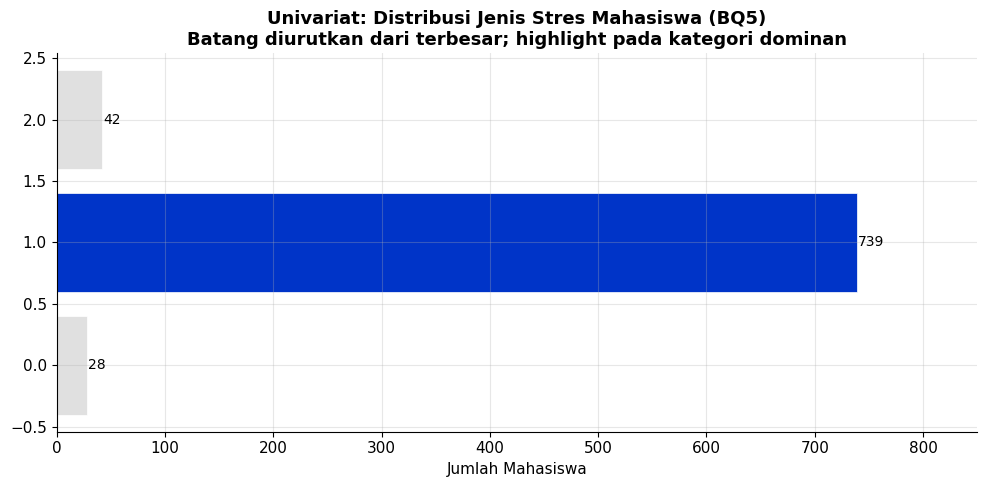

stress_type
1    739
2     42
0     28
Name: count, dtype: int64


In [14]:
sc = df_c['stress_type'].value_counts().reset_index()
sc.columns = ['stress_type', 'count']
sc = sc.sort_values('count', ascending=False).reset_index(drop=True)
colors = [C_DARK if i == 0 else C_GREY for i in range(len(sc))]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(sc['stress_type'], sc['count'], color=colors, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, sc['count']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=10)
ax.set_xlim(0, sc['count'].max() * 1.15)
ax.set_xlabel('Jumlah Mahasiswa')
ax.set_title('Univariat: Distribusi Jenis Stres Mahasiswa (BQ5)\nBatang diurutkan dari terbesar; highlight pada kategori dominan',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('uni_stress_type.png', dpi=150, bbox_inches='tight')
plt.show()

print(df_c['stress_type'].value_counts())

**Distribusi Jenis Stres**

Diagram batang horizontal diurutkan dari terbesar ke terkecil sesuai prinsip Tufte agar perbandingan terlihat sistematis. Satu warna konstan (`#e0e0e0`) digunakan untuk kategori nominal karena tidak ada urutan hierarki, dengan satu highlight (`#0034c8`) pada kategori dominan.

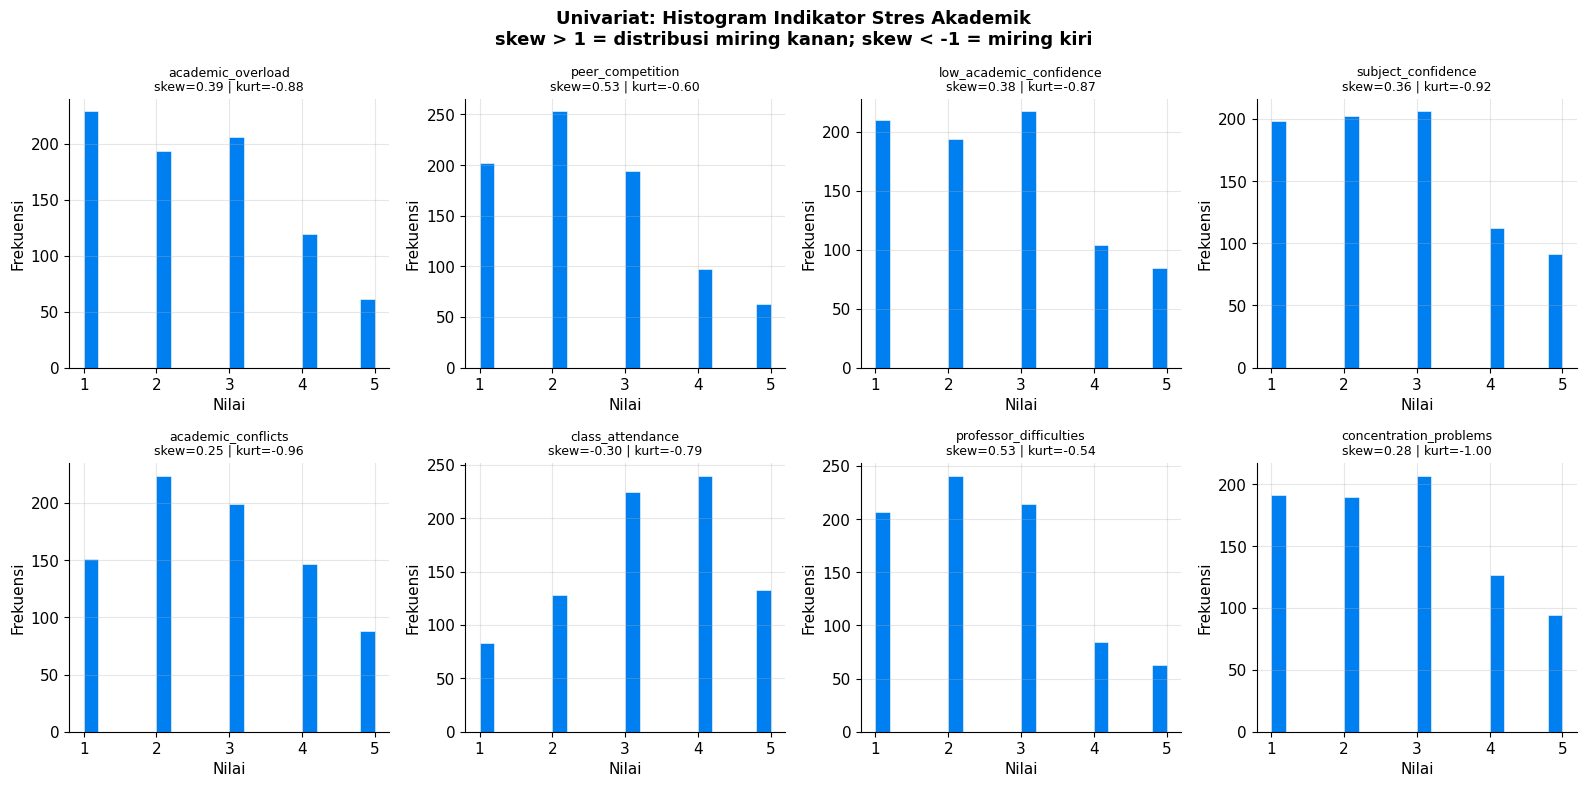

Skewness per indikator:
professor_difficulties     0.5340
peer_competition           0.5300
academic_overload          0.3890
low_academic_confidence    0.3820
subject_confidence         0.3570
concentration_problems     0.2780
academic_conflicts         0.2450
class_attendance          -0.3020
dtype: float64


In [15]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(acad):
    if col not in df_c.columns:
        continue
    skew_val = df_c[col].skew()
    kurt_val = df_c[col].kurtosis()
    axes[i].hist(df_c[col].dropna(), bins=20, color=C_MAIN, edgecolor='white', linewidth=0.4)
    axes[i].set_title(f'{col}\nskew={skew_val:.2f} | kurt={kurt_val:.2f}', fontsize=9)
    axes[i].set_xlabel('Nilai')
    axes[i].set_ylabel('Frekuensi')
for j in range(len(acad), len(axes)):
    axes[j].set_visible(False)
fig.suptitle('Univariat: Histogram Indikator Stres Akademik\nskew > 1 = distribusi miring kanan; skew < -1 = miring kiri',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('uni_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

print('Skewness per indikator:')
print(df_c[acad].skew().round(3).sort_values(ascending=False))

**Distribusi Indikator Stres Akademik**

Skewness dan kurtosis dicantumkan langsung di judul setiap histogram. Nilai `skew > 1` menandakan distribusi miring kanan, yang akan mempengaruhi pilihan statistik perbandingan (non-parametrik lebih aman).

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16568\1982288544.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([df_c[c].dropna() for c in acad], labels=acad,


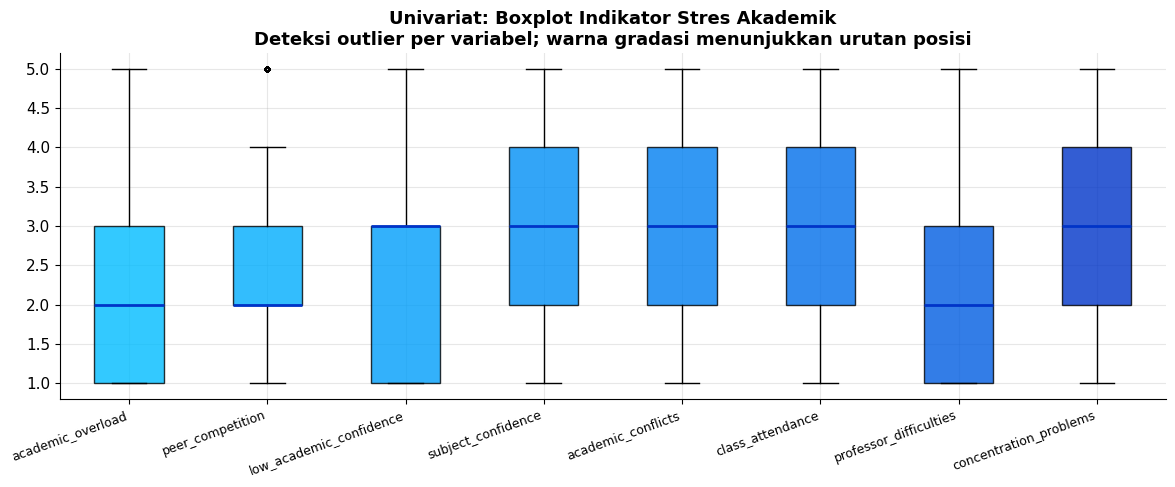

In [16]:
fig, ax = plt.subplots(figsize=(12, 5))
bp = ax.boxplot([df_c[c].dropna() for c in acad], labels=acad,
                patch_artist=True,
                medianprops=dict(color=C_DARK, linewidth=2),
                flierprops=dict(marker='o', markersize=3, color=C_DARK))
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor(PALETTE[int(i * (len(PALETTE) - 1) / max(len(acad) - 1, 1))])
    patch.set_alpha(0.8)
ax.set_xticklabels(acad, rotation=20, ha='right', fontsize=9)
ax.set_title('Univariat: Boxplot Indikator Stres Akademik\nDeteksi outlier per variabel; warna gradasi menunjukkan urutan posisi',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('uni_boxplot_indicators.png', dpi=150, bbox_inches='tight')
plt.show()

**Deteksi Outlier dengan Boxplot**

Boxplot menampilkan ringkasan lima angka statistik (min, Q1, median, Q3, max). Titik di luar *whisker* adalah outlier. Keberadaan outlier pada indikator akademik perlu diputuskan: apakah merupakan respons ekstrem yang valid atau kesalahan input.

### Analisis Bivariat

Meneliti hubungan antara dua variabel.

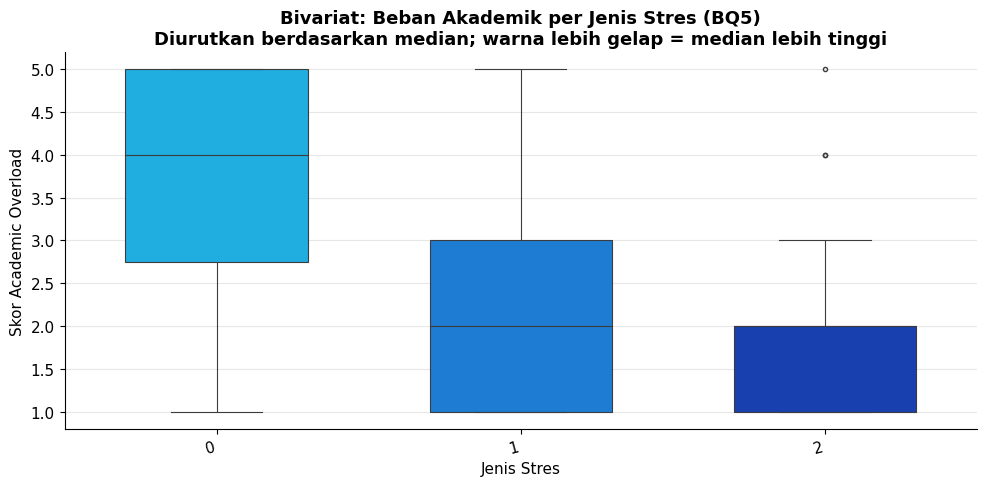

Rata-rata & Median academic_overload per stress_type:
              mean  median
stress_type               
0           3.6790  4.0000
1           2.4830  2.0000
2           1.8570  2.0000


In [17]:
if 'stress_type' in df_c.columns and 'academic_overload' in df_c.columns:
    order = df_c.groupby('stress_type')['academic_overload'].median().sort_values(ascending=False).index.tolist()
    n = len(order)
    pal = {t: PALETTE[int(i * (len(PALETTE) - 1) / max(n - 1, 1))] for i, t in enumerate(order)}

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.boxplot(data=df_c, x='stress_type', y='academic_overload',
                hue='stress_type', order=order, hue_order=order,
                palette=pal, legend=False, ax=ax,
                linewidth=0.8, width=0.6,
                flierprops=dict(marker='o', markersize=3))
    ax.set_xlabel('Jenis Stres')
    ax.set_ylabel('Skor Academic Overload')
    ax.set_title('Bivariat: Beban Akademik per Jenis Stres (BQ5)\nDiurutkan berdasarkan median; warna lebih gelap = median lebih tinggi',
                 fontsize=13, fontweight='bold')
    plt.xticks(rotation=15, ha='right')
    plt.tight_layout()
    plt.savefig('biv_stresstype_vs_overload.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('Rata-rata & Median academic_overload per stress_type:')
    print(df_c.groupby('stress_type')['academic_overload'].agg(['mean', 'median']).round(3))

**Beban Akademik per Jenis Stres (BQ5)**

Boxplot multipel digunakan untuk membandingkan sebaran `academic_overload` di setiap kelompok `stress_type`. Urutan kategori berdasarkan median (bukan alfabet) agar pola perbedaan langsung terlihat. Warna diaplikasikan via `hue=` sesuai API seaborn v0.13+.

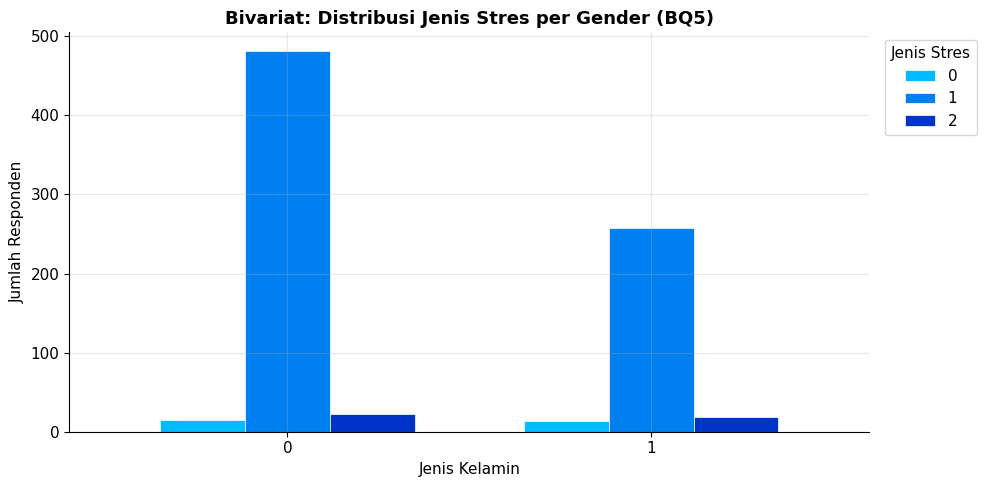

In [18]:
if 'gender' in df_c.columns and 'stress_type' in df_c.columns:
    pivot = df_c.groupby(['gender', 'stress_type']).size().unstack(fill_value=0)
    n_cols = len(pivot.columns)
    bar_colors = [PALETTE[int(i * (len(PALETTE) - 1) / max(n_cols - 1, 1))] for i in range(n_cols)]

    fig, ax = plt.subplots(figsize=(10, 5))
    pivot.plot(kind='bar', ax=ax, color=bar_colors, edgecolor='white', linewidth=0.5, width=0.7)
    ax.set_xlabel('Jenis Kelamin')
    ax.set_ylabel('Jumlah Responden')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.set_title('Bivariat: Distribusi Jenis Stres per Gender (BQ5)',
                 fontsize=13, fontweight='bold')
    ax.legend(title='Jenis Stres', bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig('biv_gender_vs_stresstype.png', dpi=150, bbox_inches='tight')
    plt.show()

**Jenis Stres per Gender**

*Clustered bar chart* untuk membandingkan frekuensi sub-kategori (`stress_type`) di dalam kategori utama (`gender`). Warna berbeda per jenis stres menggunakan palet HAPI.

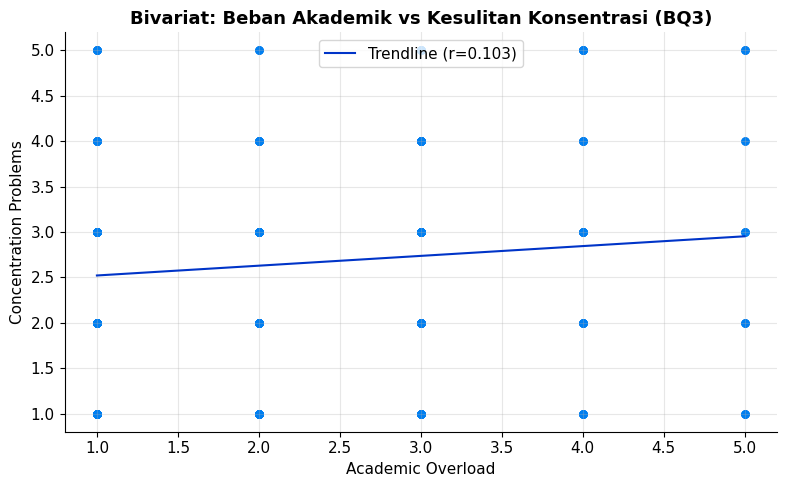

Korelasi Pearson academic_overload vs concentration_problems: r = 0.103


In [19]:
if 'academic_overload' in df_c.columns and 'concentration_problems' in df_c.columns:
    r = df_c['academic_overload'].corr(df_c['concentration_problems'])

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(df_c['academic_overload'], df_c['concentration_problems'],
               alpha=0.4, color=C_MAIN, s=25)
    m, b = np.polyfit(
        df_c['academic_overload'].dropna(),
        df_c['concentration_problems'].dropna(), 1)
    x_line = np.linspace(df_c['academic_overload'].min(), df_c['academic_overload'].max(), 100)
    ax.plot(x_line, m * x_line + b, color=C_DARK, linewidth=1.5, label=f'Trendline (r={r:.3f})')
    ax.set_xlabel('Academic Overload')
    ax.set_ylabel('Concentration Problems')
    ax.legend()
    ax.set_title('Bivariat: Beban Akademik vs Kesulitan Konsentrasi (BQ3)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('biv_overload_vs_concentration.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'Korelasi Pearson academic_overload vs concentration_problems: r = {r:.3f}')

**Beban Akademik vs Kesulitan Konsentrasi**

*Scatter plot* dengan trendline untuk melihat arah dan kekuatan hubungan dua variabel numerik. Nilai `r` (korelasi Pearson) ditampilkan di legenda sebagai ringkasan kuantitatif.

### Analisis Multivariat

Menyelidiki pola dan interaksi antara tiga variabel atau lebih.


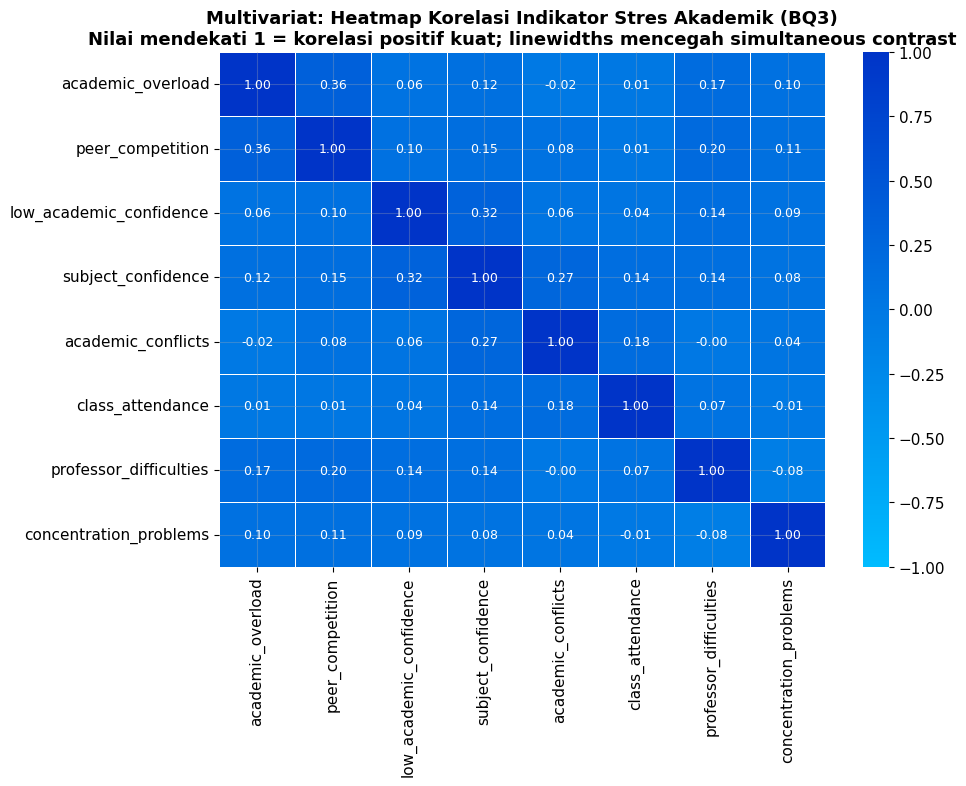

Pasangan korelasi tertinggi:
peer_competition        academic_overload         0.3550
subject_confidence      low_academic_confidence   0.3220
academic_conflicts      subject_confidence        0.2700
professor_difficulties  peer_competition          0.2010
class_attendance        academic_conflicts        0.1760
dtype: float64


In [20]:
corr = df_c[num_avail].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap=HAPI_CMAP,
            vmin=-1, vmax=1, center=0,
            linewidths=0.5, linecolor='white',
            ax=ax, annot_kws={'size': 9})
ax.set_title('Multivariat: Heatmap Korelasi Indikator Stres Akademik (BQ3)\nNilai mendekati 1 = korelasi positif kuat; linewidths mencegah simultaneous contrast',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('multi_heatmap_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('Pasangan korelasi tertinggi:')
mask = np.triu(np.ones_like(corr, dtype=bool))
corr_flat = corr.mask(mask).stack().abs().sort_values(ascending=False)
print(corr_flat.head(5).round(3))

**Heatmap Korelasi Indikator Akademik**

Heatmap menggunakan palet sekuensial HAPI. Parameter `linewidths=0.5` dan `linecolor='white'` menambahkan batas fisik antar sel untuk mencegah *simultaneous contrast* yang dapat mendistorsi persepsi warna.

In [21]:
vif_cols = [c for c in num_avail if df_c[c].notna().all()]
if len(vif_cols) >= 2:
    X_vif = df_c[vif_cols].dropna()
    vif_data = pd.DataFrame({
        'Fitur': vif_cols,
        'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(len(vif_cols))]
    }).sort_values('VIF', ascending=False).reset_index(drop=True)
    print('VIF Check (batas aman: VIF < 1000)')
    print(vif_data.round(2))
    flag = vif_data[vif_data['VIF'] >= 1000]
    if len(flag) > 0:
        print(f'Multikolinearitas tinggi terdeteksi: {flag["Fitur"].tolist()}')
    else:
        print('Semua VIF < 1000: tidak ada multikolinearitas bermasalah')

VIF Check (batas aman: VIF < 1000)
                     Fitur    VIF
0         class_attendance 6.9600
1       subject_confidence 6.3300
2         peer_competition 6.0700
3       academic_conflicts 5.8900
4        academic_overload 5.5600
5  low_academic_confidence 5.4300
6   professor_difficulties 5.2300
7   concentration_problems 4.7500
Semua VIF < 1000: tidak ada multikolinearitas bermasalah


**Uji Multikolinearitas (VIF)**

*Variance Inflation Factor* (VIF) mengukur seberapa besar satu fitur berkorelasi dengan fitur lainnya. VIF >= 1000 menandakan multikolinearitas parah yang harus ditangani sebelum pemodelan (misal dengan PCA atau menghapus salah satu fitur yang redundan).

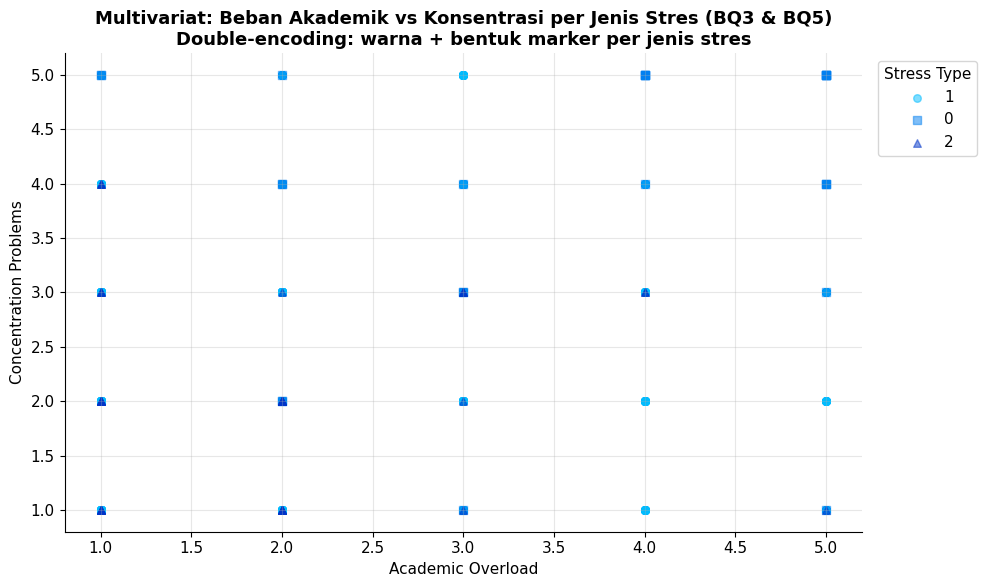

In [22]:
if all(c in df_c.columns for c in ['academic_overload', 'concentration_problems', 'stress_type']):
    types = df_c['stress_type'].dropna().unique()
    cmap_3 = {t: PALETTE[int(i * (len(PALETTE) - 1) / max(len(types) - 1, 1))] for i, t in enumerate(types)}
    mkr_map = {t: m for t, m in zip(types, ['o', 's', '^', 'D', 'v', '<', '>'])}

    fig, ax = plt.subplots(figsize=(10, 6))
    for stype in types:
        mask = df_c['stress_type'] == stype
        ax.scatter(
            df_c.loc[mask, 'academic_overload'],
            df_c.loc[mask, 'concentration_problems'],
            c=cmap_3[stype], marker=mkr_map.get(stype, 'o'),
            alpha=0.5, s=30, label=stype)
    ax.set_xlabel('Academic Overload')
    ax.set_ylabel('Concentration Problems')
    ax.legend(title='Stress Type', bbox_to_anchor=(1.01, 1), loc='upper left')
    ax.set_title('Multivariat: Beban Akademik vs Konsentrasi per Jenis Stres (BQ3 & BQ5)\nDouble-encoding: warna + bentuk marker per jenis stres',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('multi_scatter_3var.png', dpi=150, bbox_inches='tight')
    plt.show()

**Scatter Plot 3 Variabel**

Tiga variabel divisualisasikan sekaligus: sumbu X dan Y untuk dua variabel numerik, sedangkan variabel ketiga (`stress_type`) dikodekan dengan warna *dan* bentuk marker (*double-encoding*). Teknik ini mempertahankan aksesibilitas bagi pengguna dengan gangguan persepsi warna.

### Rekomendasi Pemodelan

In [23]:
print('Ringkasan EDA: Stress Indicators')
print(f'Total responden : {len(df_c):,}')
print(f'Indikator akademik dianalisis: {len(acad)}')

print('\nTop 3 indikator akademik (rata-rata tertinggi):')
print(df_c[acad].mean().sort_values(ascending=False).head(3).round(3))

print('\nDistribusi stress_type:')
print(df_c['stress_type'].value_counts())

Ringkasan EDA: Stress Indicators
Total responden : 809
Indikator akademik dianalisis: 8

Top 3 indikator akademik (rata-rata tertinggi):
class_attendance         3.2620
academic_conflicts       2.7490
concentration_problems   2.6820
dtype: float64

Distribusi stress_type:
stress_type
1    739
2     42
0     28
Name: count, dtype: int64


**Rekomendasi**

- Indikator dengan rata-rata tertinggi adalah kandidat fitur terkuat. Korelasi di heatmap memperlihatkan cluster indikator yang saling berkaitan erat.
- Distribusi `stress_type` yang tidak merata memerlukan *class weighting* atau *oversampling* saat membangun model klasifikasi jenis stres.
- Jika hubungan antar indikator bersifat linier kuat (r > 0.7), rekomendasikan model **Regresi Logistik** atau **Random Forest** dengan regularisasi untuk menghindari overfitting akibat multikolinearitas.